<a href="https://colab.research.google.com/github/anujman90-byte/Deep-Learning/blob/main/Satellite_Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Satellite Image Classification

- This dataset from Kaggle contains images taken from satellites with 4 categories: Forests or green areas, cloudy, desert, water bodies
- The problem statement is to classify images into these 4 categories

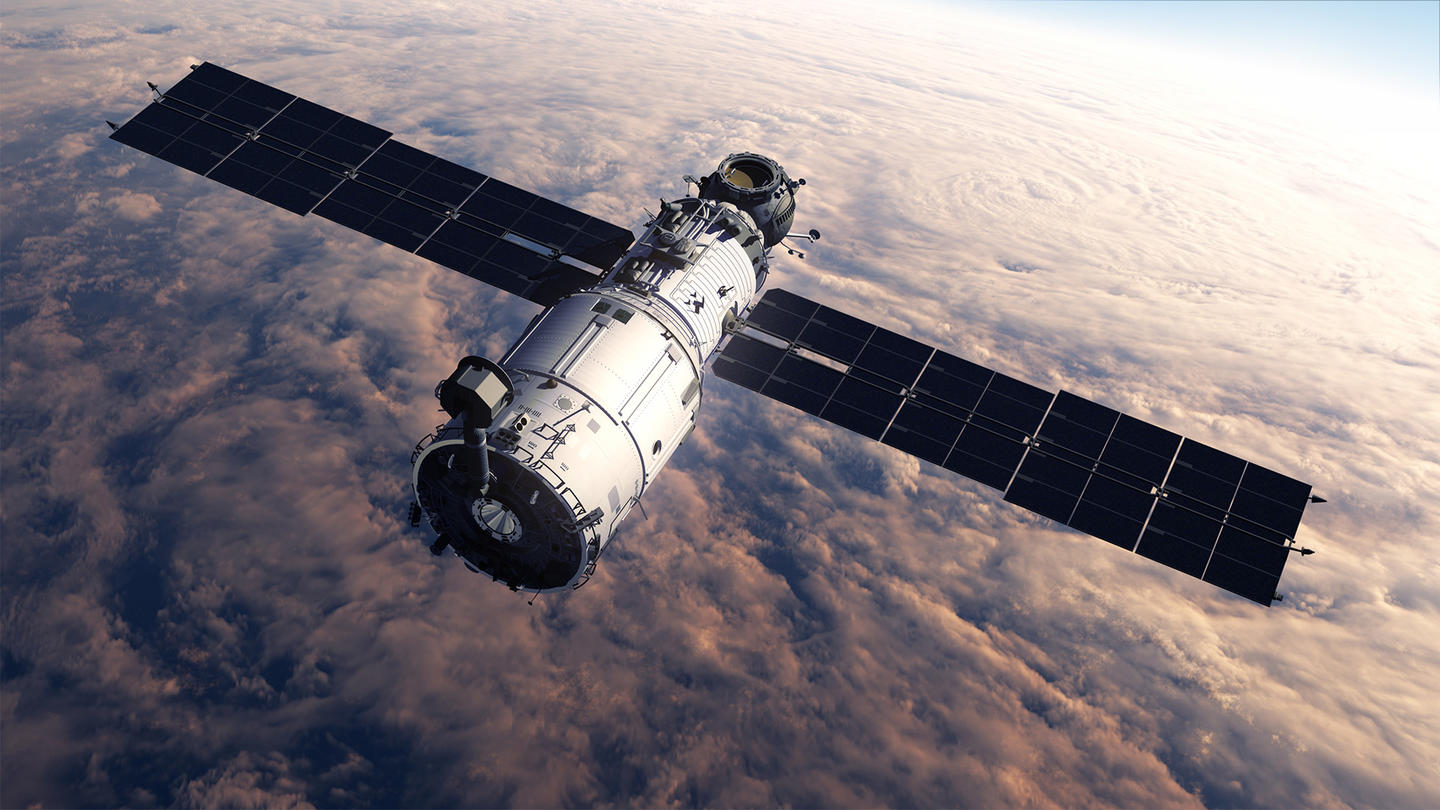

# Load necessary libraries

In [ ]:
import numpy as np
import tensorflow as tf
import pandas as pd
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, Dropout, GlobalMaxPooling2D, BatchNormalization, MaxPooling2D
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.callbacks import EarlyStopping

# Load datasets

In [ ]:
import kagglehub

path = kagglehub.dataset_download("mahmoudreda55/satellite-image-classification")

print("Path to dataset files:", path)

100%|██████████| 21.8M/21.8M [00:02<00:00, 11.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/mahmoudreda55/satellite-image-classification/versions/1


In [ ]:
import os

dataset_path = os.path.join(path, 'data')

print(f"Contents of the dataset directory: {dataset_path}")
print(os.listdir(dataset_path)) # List contents of the actual data directory

Contents of the dataset directory: /root/.cache/kagglehub/datasets/mahmoudreda55/satellite-image-classification/versions/1/data
['green_area', 'cloudy', 'desert', 'water']


# EDA 1: Determine number of images per class

In [ ]:
image_counts = {}
total_images = 0

# Iterate through each subdirectory (class)
for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)
    if os.path.isdir(class_path):
        # Count image files (assuming common image extensions)
        num_images = len([f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))])
        image_counts[class_name] = num_images
        total_images += num_images

print("Number of images per class:")
for class_name, count in image_counts.items():
    print(f"  {class_name}: {count} images")

print(f"\nTotal number of images: {total_images}")

Number of images per class:
  green_area: 1500 images
  cloudy: 1500 images
  desert: 1131 images
  water: 1500 images

Total number of images: 5631


# EDA 2: Visualize dataset

Display one image from each class to get touch & feel for the dataset

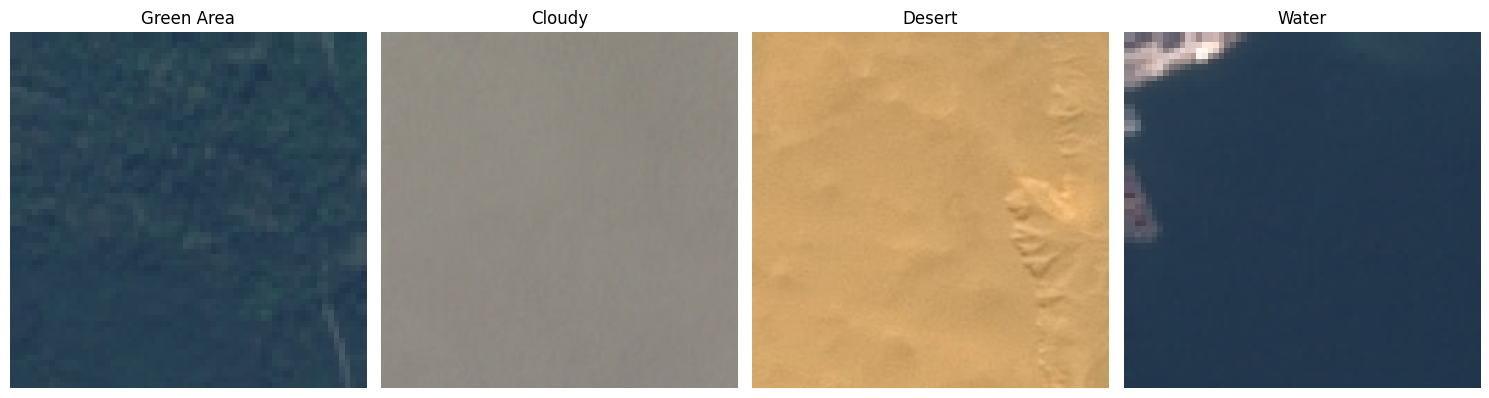

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random

# Create a figure to display images
plt.figure(figsize=(15, 5))

# Iterate through each class and display one image
for i, class_name in enumerate(image_counts.keys()):
    class_path = os.path.join(dataset_path, class_name)

    # Get a list of all image files in the current class directory
    image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]

    if image_files:
        # Pick a random image from the list
        selected_image_name = random.choice(image_files)
        image_path = os.path.join(class_path, selected_image_name)

        # Load and display the image
        img = Image.open(image_path)
        plt.subplot(1, len(image_counts), i + 1) # Create subplots for each image
        plt.imshow(img)
        plt.title(class_name.replace('_', ' ').title()) # Display class name as title
        plt.axis('off') # Hide axes
    else:
        print(f"No images found in class: {class_name}")

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

# Pre-Process Dataset before train-validate-test split

In [ ]:
from sklearn.model_selection import train_test_split
import os

# Prepare data for splitting
all_image_paths = []
all_image_labels = []

# Create a mapping from class name to integer label
class_names = sorted(os.listdir(dataset_path))
class_to_label = {name: i for i, name in enumerate(class_names)}
label_to_class = {i: name for i, name in enumerate(class_names)}

for class_name in class_names:
    class_path = os.path.join(dataset_path, class_name)
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            if img_name.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
                all_image_paths.append(os.path.join(class_path, img_name))
                all_image_labels.append(class_to_label[class_name])

# Convert to numpy arrays for train_test_split
all_image_paths = np.array(all_image_paths)
all_image_labels = np.array(all_image_labels)

print(f"Total images found: {len(all_image_paths)}")
print(f"Total labels found: {len(all_image_labels)}")

Total images found: 5631
Total labels found: 5631


# Split dataset into Train-Validate-Test datasets

- Adopt a 80-10-10 split for train-validate-test datasets
- Ensure datasets are stratified. i.e., images from every class should be represented in the train-validate-test datasets

In [ ]:
# First split: 80% train, 20% temp (for test and validation)
X_train, X_temp, y_train, y_temp = train_test_split(
    all_image_paths, all_image_labels, test_size=0.2, stratify=all_image_labels, random_state=42
)

# Second split: 10% test, 10% validation from the 20% temp set
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print(f"Train set size: {len(X_train)} images")
print(f"Validation set size: {len(X_val)} images")
print(f"Test set size: {len(X_test)} images")

# Verify stratification
print("\nClass distribution in Training set:")
for label in np.unique(y_train):
    count = np.sum(y_train == label)
    print(f"  {label_to_class[label]}: {count} images ({count / len(y_train) * 100:.2f}%) ")

print("\nClass distribution in Validation set:")
for label in np.unique(y_val):
    count = np.sum(y_val == label)
    print(f"  {label_to_class[label]}: {count} images ({count / len(y_val) * 100:.2f}%) ")

print("\nClass distribution in Test set:")
for label in np.unique(y_test):
    count = np.sum(y_test == label)
    print(f"  {label_to_class[label]}: {count} images ({count / len(y_test) * 100:.2f}%) ")

Train set size: 4504 images
Validation set size: 563 images
Test set size: 564 images

Class distribution in Training set:
  cloudy: 1200 images (26.64%) 
  desert: 904 images (20.07%) 
  green_area: 1200 images (26.64%) 
  water: 1200 images (26.64%) 

Class distribution in Validation set:
  cloudy: 150 images (26.64%) 
  desert: 113 images (20.07%) 
  green_area: 150 images (26.64%) 
  water: 150 images (26.64%) 

Class distribution in Test set:
  cloudy: 150 images (26.60%) 
  desert: 114 images (20.21%) 
  green_area: 150 images (26.60%) 
  water: 150 images (26.60%) 


# Pre-process data before CNN

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import pandas as pd

# Define image dimensions and batch size
IMG_HEIGHT = 150
IMG_WIDTH = 150
BATCH_SIZE = 32

# Data augmentation and preprocessing for training data
train_datagen = ImageDataGenerator(
    rescale=1./255, # Normalize pixel values to [0, 1]
    rotation_range=20, # Rotate images by up to 20 degrees
    width_shift_range=0.2, # Shift images horizontally by up to 20% of the width
    height_shift_range=0.2, # Shift images vertically by up to 20% of the height
    shear_range=0.2, # Apply shearing transformations
    zoom_range=0.2, # Apply zooming transformations
    horizontal_flip=True, # Randomly flip images horizontally
    fill_mode='nearest' # Fill new pixels created by transformations
)

# Preprocessing for validation and test data (only rescaling)
validation_test_datagen = ImageDataGenerator(rescale=1./255)

# Convert integer labels to class names for flow_from_dataframe
y_train_class_names = [label_to_class[label] for label in y_train]
y_val_class_names = [label_to_class[label] for label in y_val]
y_test_class_names = [label_to_class[label] for label in y_test]

# Create DataFrames for the generators
train_df = pd.DataFrame({'filepath': X_train, 'label': y_train_class_names})
val_df = pd.DataFrame({'filepath': X_val, 'label': y_val_class_names})
test_df = pd.DataFrame({'filepath': X_test, 'label': y_test_class_names})

# Create data generators using flow_from_dataframe
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='label',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

validation_generator = validation_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='filepath',
    y_col='label',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = validation_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filepath',
    y_col='label',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False # Keep data in order for evaluation
)

print("Data generators created successfully.")

Found 4504 validated image filenames belonging to 4 classes.
Found 563 validated image filenames belonging to 4 classes.
Found 564 validated image filenames belonging to 4 classes.
Data generators created successfully.


# Design CNN for the image classification
- Two Conv2D layers
- One dense layer after flattening operation
- Use regularization techniques: batch normalization, Maxpooling, Dropout to prevent overfitting
- Use Softmax since this is a multi-classification problem. For binary classification problems use Sigmoid
- Compile model using Adam

In [ ]:
num_classes = len(class_names)

# Define the input shape
input_shape = (IMG_HEIGHT, IMG_WIDTH, 3) # 3 for RGB images

# Build the CNN model
i = Input(shape=input_shape)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(i)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)

x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)

x = Flatten()(x)
x = Dropout(0.5)(x) # Dropout for regularization
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(num_classes, activation='softmax')(x)

model = Model(i, x)

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Print model summary
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 87616)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 87616)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,214,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,235,268 (42.86 MB)

 Trainable params: 11,235,076 (42.86 MB)

 Non-trainable params: 192 (768.00 B)

# Run CNN

In [ ]:
NUM_EPOCHS = 10

# Train the model
r = model.fit(
    train_generator,
    epochs=NUM_EPOCHS,
    validation_data=validation_generator
)

Epoch 1/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 336s 2s/step - accuracy: 0.7433 - loss: 4.1955 - val_accuracy: 0.2664 - val_loss: 24.3286
Epoch 2/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 325s 2s/step - accuracy: 0.7655 - loss: 0.6443 - val_accuracy: 0.2629 - val_loss: 21.8257
Epoch 3/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 327s 2s/step - accuracy: 0.7502 - loss: 0.6307 - val_accuracy: 0.4103 - val_loss: 8.0087
Epoch 4/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 327s 2s/step - accuracy: 0.7709 - loss: 0.5723 - val_accuracy: 0.6234 - val_loss: 1.3016
Epoch 5/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 325s 2s/step - accuracy: 0.7755 - loss: 0.5846 - val_accuracy: 0.8011 - val_loss: 0.6403
Epoch 6/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 327s 2s/step - accuracy: 0.7913 - loss: 0.5082 - val_accuracy: 0.7762 - val_loss: 0.4578
Epoch 7/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 332s 2s/step - accuracy: 0.7711 - loss: 0.5221 - val_accuracy: 0.8721 - val_loss: 0.3344
Epoch 8/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 329s 2s/step - accuracy: 0.7871 - loss: 0.5389 - val_ac

# Run Model.Predict on test datasets & calculate test dataset accuracy

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Get predictions
test_generator.reset() # Ensure predictions are in order
predictions = model.predict(test_generator, steps=test_generator.samples // BATCH_SIZE + 1)

# Get predicted class labels
predicted_classes = np.argmax(predictions, axis=1)

print("Predictions generated successfully.")

18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 463ms/step
Predictions generated successfully.


In [ ]:
from sklearn.metrics import accuracy_score

# Get true labels from the test generator
true_classes = test_generator.classes

# Calculate accuracy
accuracy = accuracy_score(true_classes, predicted_classes)

print(f"Test set accuracy: {accuracy:.4f}")

Test set accuracy: 0.9113


# Create confusion matrix

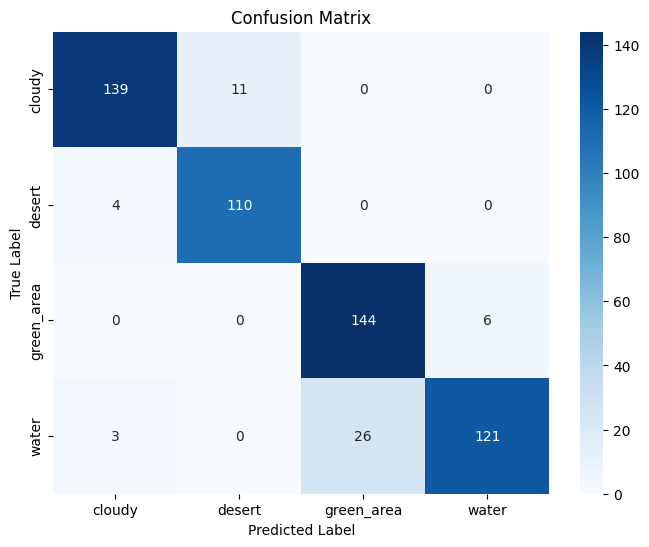


Classification Report:
              precision    recall  f1-score   support

      cloudy       0.95      0.93      0.94       150
      desert       0.91      0.96      0.94       114
  green_area       0.85      0.96      0.90       150
       water       0.95      0.81      0.87       150

    accuracy                           0.91       564
   macro avg       0.92      0.91      0.91       564
weighted avg       0.92      0.91      0.91       564



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Compute the confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

# Get class names for better readability
class_labels = list(label_to_class.values())

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Print classification report
print('\nClassification Report:')
print(classification_report(true_classes, predicted_classes, target_names=class_labels))

# Visualize misclassified images

Total misclassified images: 50

Most common misclassification patterns:
  True: water, Predicted: green_area (Count: 26)


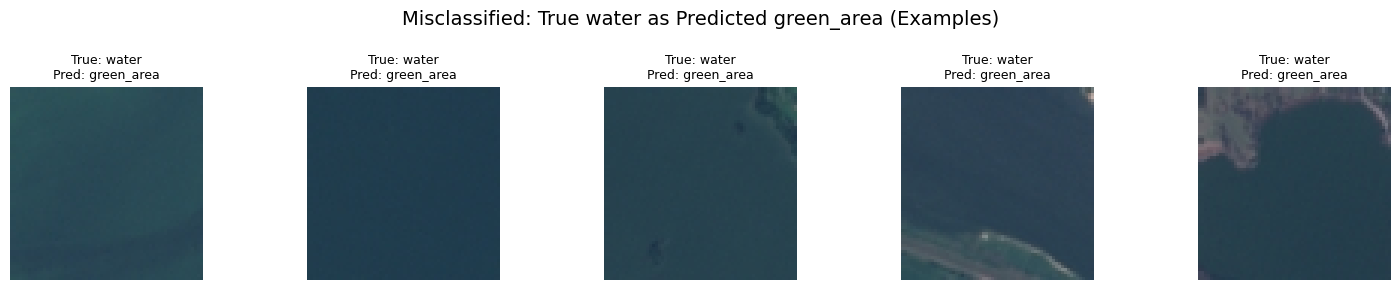

  True: cloudy, Predicted: desert (Count: 11)


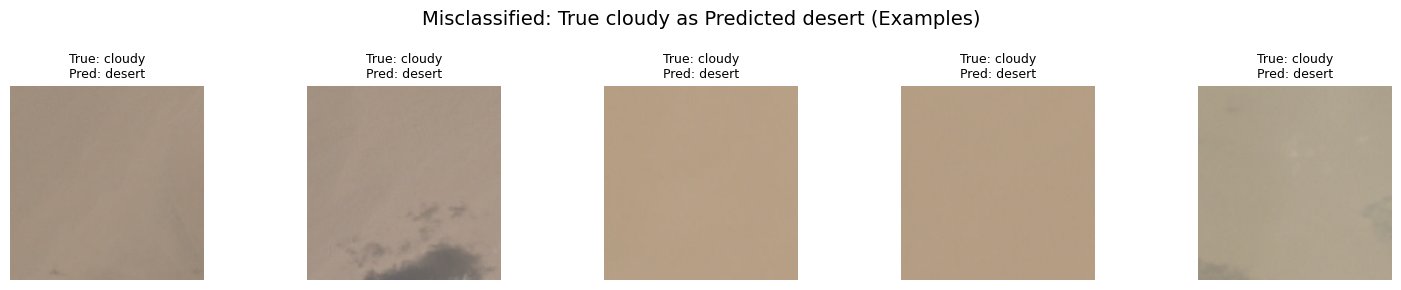

  True: green_area, Predicted: water (Count: 6)


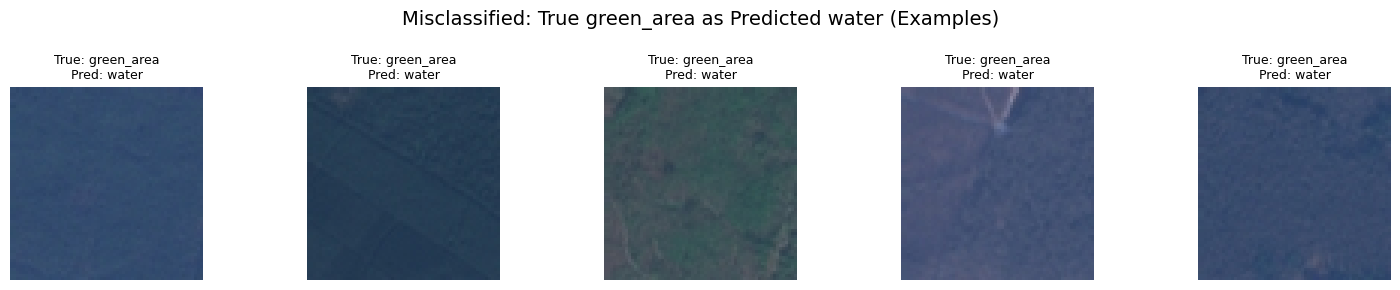


...and 2 more misclassification types.


In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random

# Find misclassified indices
misclassified_indices = np.where(true_classes != predicted_classes)[0]

if len(misclassified_indices) == 0:
    print("No misclassified images found.")
else:
    print(f"Total misclassified images: {len(misclassified_indices)}")

    # Dictionary to store misclassified pairs (true_label, predicted_label)
    misclassified_pairs = {}

    for idx in misclassified_indices:
        true_label = true_classes[idx]
        predicted_label = predicted_classes[idx]
        pair = (true_label, predicted_label)
        if pair not in misclassified_pairs:
            misclassified_pairs[pair] = []
        misclassified_pairs[pair].append(idx)

    # Sort misclassified pairs by count (most common first)
    sorted_misclassified_pairs = sorted(misclassified_pairs.items(), key=lambda item: len(item[1]), reverse=True)

    print('\nMost common misclassification patterns:')
    num_to_display = min(3, len(sorted_misclassified_pairs))

    for i in range(num_to_display):
        pair, indices = sorted_misclassified_pairs[i]
        true_class_name = label_to_class[pair[0]]
        predicted_class_name = label_to_class[pair[1]]
        print(f"  True: {true_class_name}, Predicted: {predicted_class_name} (Count: {len(indices)})")

        # Display up to 5 random examples for this misclassification type
        plt.figure(figsize=(15, 3))
        plt.suptitle(f'Misclassified: True {true_class_name} as Predicted {predicted_class_name} (Examples)', fontsize=14)

        examples_to_show = random.sample(indices, min(5, len(indices)))

        for j, img_idx in enumerate(examples_to_show):
            image_path = X_test[img_idx]
            img = Image.open(image_path)
            plt.subplot(1, min(5, len(indices)), j + 1)
            plt.imshow(img)
            plt.title(f'True: {true_class_name}\nPred: {predicted_class_name}', fontsize=9)
            plt.axis('off')
        plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle
        plt.show()

    if len(sorted_misclassified_pairs) > num_to_display:
        print(f'\n...and {len(sorted_misclassified_pairs) - num_to_display} more misclassification types.')

# Plot loss & accuracy curves

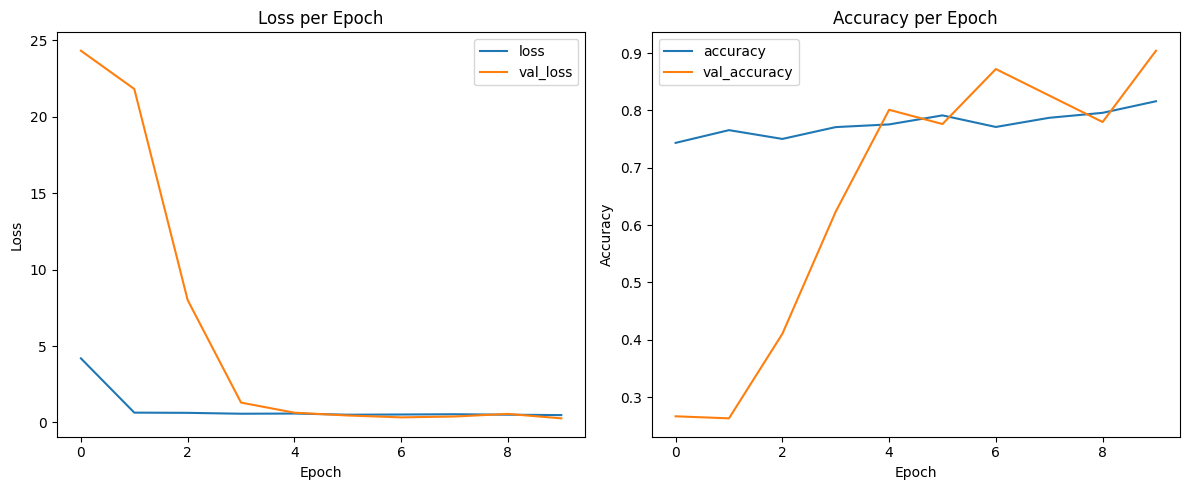

In [ ]:
import matplotlib.pyplot as plt

# Plot loss per epoch
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.title('Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot accuracy per epoch
plt.subplot(1, 2, 2)
plt.plot(r.history['accuracy'], label='accuracy')
plt.plot(r.history['val_accuracy'], label='val_accuracy')
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()